# 06 — Train, tune, and evaluate

Average precision (PR-AUC) is primary because late orders are uncommon. A majority dummy establishes the trivial baseline. Logistic-regression hyperparameters and threshold use validation only; test data is loaded only after every choice is frozen.

In [1]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert ROOT.name == "02-olist-late-delivery-ml"
SEED = 42
pd.set_option("display.max_columns", 100)
import matplotlib.pyplot as plt
import joblib
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_recall_curve,
)

feature_dir = ROOT / "artifacts/05_features"
X_train = pd.read_parquet(feature_dir / "X_train.parquet")
y_train = pd.read_parquet(feature_dir / "y_train.parquet")["late"]
X_validation = pd.read_parquet(feature_dir / "X_validation.parquet")
y_validation = pd.read_parquet(feature_dir / "y_validation.parquet")["late"]

def classification_metrics(y_true, prediction, probability):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "average_precision": average_precision_score(y_true, probability),
        "confusion_matrix": confusion_matrix(y_true, prediction).tolist(),
    }

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_validation_probability = dummy.predict_proba(X_validation)[:, 1]
dummy_validation = classification_metrics(
    y_validation, dummy.predict(X_validation), dummy_validation_probability
)
dummy_validation

{'accuracy': 0.9568792757929653,
 'precision': np.float64(0.0),
 'recall': np.float64(0.0),
 'f1': np.float64(0.0),
 'roc_auc': np.float64(0.5),
 'average_precision': np.float64(0.04312072420703476),
 'confusion_matrix': [[13847, 0], [624, 0]]}

## Validation-only candidate comparison

Every `C`/class-weight combination is fitted on training and scored on validation. The compact table makes selection auditable; the maximum validation PR-AUC wins, with ROC-AUC shown as secondary evidence.

In [2]:
candidates = []
candidate_models = {}
candidate_probabilities = {}
for C in [0.01, 0.1, 1.0, 10.0]:
    for class_weight in [None, "balanced"]:
        model = LogisticRegression(
            C=C,
            class_weight=class_weight,
            max_iter=1000,
            random_state=SEED,
            solver="liblinear",
        ).fit(X_train, y_train)
        key = (C, str(class_weight))
        probability = model.predict_proba(X_validation)[:, 1]
        candidates.append({
            "C": C,
            "class_weight": str(class_weight),
            "validation_average_precision": average_precision_score(y_validation, probability),
            "validation_roc_auc": roc_auc_score(y_validation, probability),
        })
        candidate_models[key] = model
        candidate_probabilities[key] = probability

candidate_table = pd.DataFrame(candidates).sort_values(
    ["validation_average_precision", "validation_roc_auc"], ascending=False
).reset_index(drop=True)
display(candidate_table)

winner = candidate_table.iloc[0]
winner_key = (float(winner.C), winner.class_weight)
final_model = candidate_models[winner_key]
validation_probability = candidate_probabilities[winner_key]
winner.to_dict()

,C,class_weight,validation_average_precision,validation_roc_auc
0,1.00,None,0.137382,0.773982
1,10.00,None,0.137091,0.772329
2,0.10,None,0.135506,0.777394
3,0.01,None,0.131157,0.775046
4,10.00,balanced,0.129390,0.767311
5,1.00,balanced,0.129231,0.767987
6,0.10,balanced,0.128321,0.771116
7,0.01,balanced,0.125739,0.772858


{'C': 1.0,
 'class_weight': 'None',
 'validation_average_precision': 0.13738241833753784,
 'validation_roc_auc': 0.7739818677747471}

## Validation-only threshold selection

The precision-recall curve supplies every possible validation threshold. F1 is computed for each and the maximum selected. A local table around the winner plus an inline plot shows the trade-off; test remains unopened.

,threshold,precision,recall,f1
13055,0.156849,0.162411,0.366987,0.225172
13056,0.156937,0.162527,0.366987,0.225283
13057,0.156981,0.162642,0.366987,0.225394
13058,0.156995,0.162758,0.366987,0.225505
13059,0.157136,0.162162,0.365385,0.224631
13060,0.157214,0.162278,0.365385,0.224741
13061,0.157290,0.161681,0.363782,0.223866


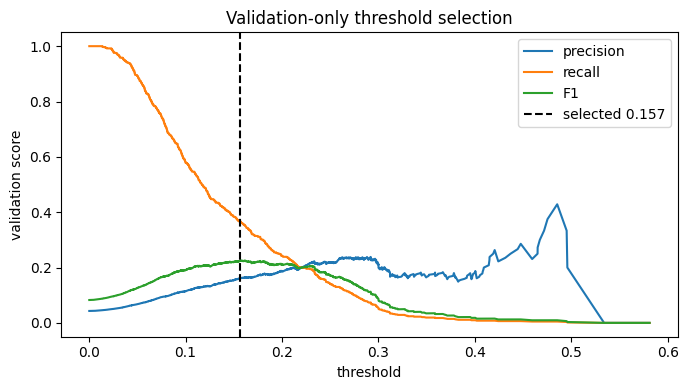

{'primary_metric': 'average_precision',
 'best_C': 1.0,
 'best_class_weight': None,
 'threshold': 0.15699537486646237,
 'threshold_criterion': 'maximum validation F1',
 'validation': {'accuracy': 0.8912998410614332,
  'precision': np.float64(0.16275764036958068),
  'recall': np.float64(0.36698717948717946),
  'f1': np.float64(0.22550467749876907),
  'roc_auc': np.float64(0.7739818677747471),
  'average_precision': np.float64(0.13738241833753784),
  'confusion_matrix': [[12669, 1178], [395, 229]]}}

In [3]:
precision, recall, thresholds = precision_recall_curve(
    y_validation, validation_probability
)
threshold_f1 = (
    2 * precision[:-1] * recall[:-1]
    / np.maximum(precision[:-1] + recall[:-1], 1e-12)
)
best_index = int(np.argmax(threshold_f1))
threshold = float(thresholds[best_index])
threshold_evidence = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": threshold_f1,
})
display(threshold_evidence.iloc[max(0, best_index-3):best_index+4])

validation_prediction = (validation_probability >= threshold).astype(int)
final_validation = classification_metrics(
    y_validation, validation_prediction, validation_probability
)
selection = {
    "primary_metric": "average_precision",
    "best_C": float(winner.C),
    "best_class_weight": None if winner.class_weight == "None" else winner.class_weight,
    "threshold": threshold,
    "threshold_criterion": "maximum validation F1",
    "validation": final_validation,
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precision[:-1], label="precision")
ax.plot(thresholds, recall[:-1], label="recall")
ax.plot(thresholds, threshold_f1, label="F1")
ax.axvline(threshold, color="black", linestyle="--", label=f"selected {threshold:.3f}")
ax.set(xlabel="threshold", ylabel="validation score", title="Validation-only threshold selection")
ax.legend()
fig.tight_layout()
plt.show()
selection

## One-time final test evaluation

Only now—after features, preprocessing, model, hyperparameters, and threshold are frozen—are test labels loaded and evaluated. No later cell changes a modeling decision.

In [4]:
X_test = pd.read_parquet(feature_dir / "X_test.parquet")
y_test = pd.read_parquet(feature_dir / "y_test.parquet")["late"]

test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= threshold).astype(int)
final_test = classification_metrics(y_test, test_prediction, test_probability)

dummy_test_probability = dummy.predict_proba(X_test)[:, 1]
dummy_test = classification_metrics(
    y_test, dummy.predict(X_test), dummy_test_probability
)
results = {
    "validation_candidates": candidate_table.to_dict(orient="records"),
    "selection": selection,
    "dummy": {
        "strategy": "most_frequent",
        "validation": dummy_validation,
        "test": dummy_test,
    },
    "final_model": {"type": "LogisticRegression", "test": final_test},
}
results

{'validation_candidates': [{'C': 1.0,
   'class_weight': 'None',
   'validation_average_precision': 0.13738241833753784,
   'validation_roc_auc': 0.7739818677747471},
  {'C': 10.0,
   'class_weight': 'None',
   'validation_average_precision': 0.13709090522083667,
   'validation_roc_auc': 0.77232942246122},
  {'C': 0.1,
   'class_weight': 'None',
   'validation_average_precision': 0.1355058996288129,
   'validation_roc_auc': 0.7773936963111513},
  {'C': 0.01,
   'class_weight': 'None',
   'validation_average_precision': 0.131157422309462,
   'validation_roc_auc': 0.7750463860541856},
  {'C': 10.0,
   'class_weight': 'balanced',
   'validation_average_precision': 0.1293900962613695,
   'validation_roc_auc': 0.7673106319428628},
  {'C': 1.0,
   'class_weight': 'balanced',
   'validation_average_precision': 0.129231306176838,
   'validation_roc_auc': 0.7679868637657328},
  {'C': 0.1,
   'class_weight': 'balanced',
   'validation_average_precision': 0.1283209804960821,
   'validation_roc_au

## Persist results and render final diagnostics

The trained model, exact JSON metrics, concise Markdown summary, and figures form the final contract. Evaluation plots are saved and also displayed inline for repository review.

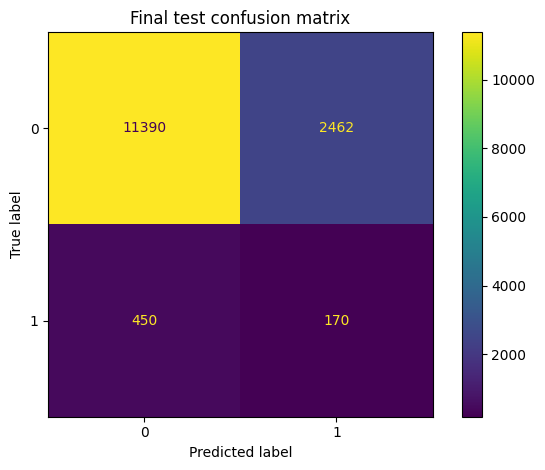

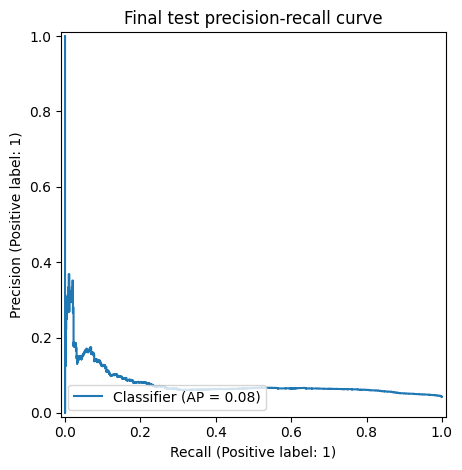

# Model results

Validation average precision selected logistic regression (`C=1.0`, `class_weight=None`). Threshold `0.1570` maximized validation F1.

| Evaluation | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Dummy validation | 0.9569 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0431 |
| Final validation | 0.8913 | 0.1628 | 0.3670 | 0.2255 | 0.7740 | 0.1374 |
| Dummy test | 0.9572 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0428 |
| Final test | 0.7988 | 0.0646 | 0.2742 | 0.1046 | 0.6514 | 0.0784 |

Test was evaluated once after all choices were frozen.



In [5]:
out = ROOT / "artifacts/06_model"
figdir = out / "figures"
figdir.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, out / "model.joblib")
(out / "metrics.json").write_text(json.dumps(results, indent=2))

summary = f"""# Model results

Validation average precision selected logistic regression (`C={winner.C}`, `class_weight={selection['best_class_weight']}`). Threshold `{threshold:.4f}` maximized validation F1.

| Evaluation | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Dummy validation | {dummy_validation['accuracy']:.4f} | {dummy_validation['precision']:.4f} | {dummy_validation['recall']:.4f} | {dummy_validation['f1']:.4f} | {dummy_validation['roc_auc']:.4f} | {dummy_validation['average_precision']:.4f} |
| Final validation | {final_validation['accuracy']:.4f} | {final_validation['precision']:.4f} | {final_validation['recall']:.4f} | {final_validation['f1']:.4f} | {final_validation['roc_auc']:.4f} | {final_validation['average_precision']:.4f} |
| Dummy test | {dummy_test['accuracy']:.4f} | {dummy_test['precision']:.4f} | {dummy_test['recall']:.4f} | {dummy_test['f1']:.4f} | {dummy_test['roc_auc']:.4f} | {dummy_test['average_precision']:.4f} |
| Final test | {final_test['accuracy']:.4f} | {final_test['precision']:.4f} | {final_test['recall']:.4f} | {final_test['f1']:.4f} | {final_test['roc_auc']:.4f} | {final_test['average_precision']:.4f} |

Test was evaluated once after all choices were frozen.
"""
(out / "results_summary.md").write_text(summary)

ConfusionMatrixDisplay.from_predictions(y_test, test_prediction)
plt.title("Final test confusion matrix")
plt.tight_layout()
plt.savefig(figdir / "confusion_matrix.png", dpi=140)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_probability)
plt.title("Final test precision-recall curve")
plt.tight_layout()
plt.savefig(figdir / "precision_recall_curve.png", dpi=140)
plt.show()
print(summary)